# Test de différentes interpolations

In [11]:
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt


df = pd.read_csv("../data/data_02923X0007_F.csv", sep=";")

df['time'] = pd.to_datetime(df['time'])
df.set_index('time', inplace=True)

df['niveau_nappe_eau'] = pd.to_numeric(df['niveau_nappe_eau'], errors='coerce')





## Interpolation linéaire

In [12]:
df['niveau_interp_linear'] = df['niveau_nappe_eau'].interpolate(
    method='linear',
    limit_direction='both'
)

## Interpolation spline cubique

In [16]:
x = np.arange(len(df))
y = df['niveau_nappe_eau'].values
mask = ~np.isnan(y)  # seulement les valeurs connues

f_cubic = interp1d(x[mask], y[mask], kind='cubic', fill_value="extrapolate")
df['niveau_interp_cubic'] = f_cubic(x)

## Resultat

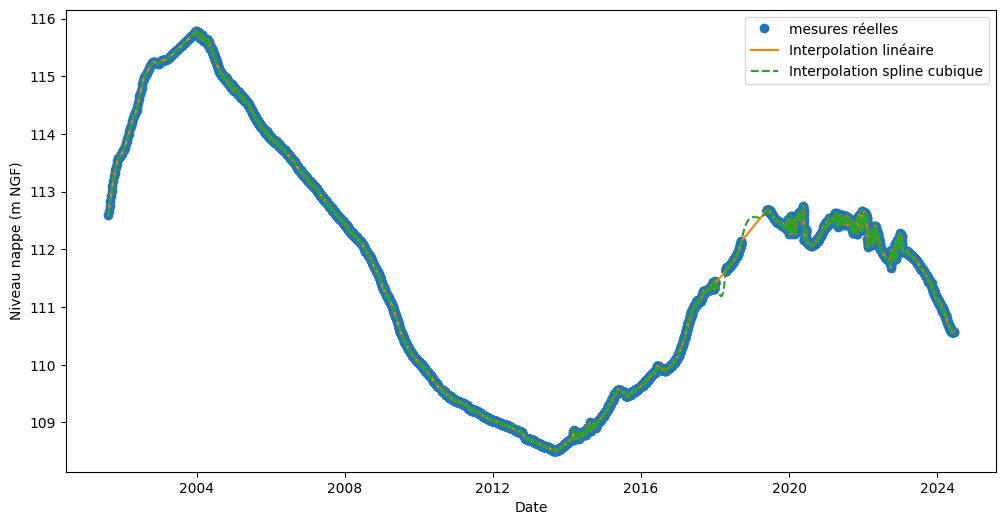

In [18]:
plt.figure(figsize=(12,6))
plt.plot(df['niveau_nappe_eau'], 'o', label='mesures réelles')
plt.plot(df['niveau_interp_linear'], '-', label='Interpolation linéaire')
plt.plot(df['niveau_interp_cubic'], '--', label='Interpolation spline cubique')
plt.xlabel("Date")
plt.ylabel("Niveau nappe (m NGF)")
plt.legend()
plt.show()